# Import Library

In [1]:
# %pip install numpy
import numpy as np
import matplotlib as plt
import seaborn as sns
import requests
import pandas as pd
from bs4 import BeautifulSoup
import openpyxl

# Scrapping Website CoinMarketCap

In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import openpyxl
def scappe(): 
    url = 'https://coinmarketcap.com/gainers-losers/'
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'
    }
    

    try:
        response = requests.get(url, headers=headers)
    except Exception as e:
        print(f"Koneksi gagal: {e}")
        return [], []
    
    if response.status_code != 200:
        print(f'Error: {response.status_code}')
        return [], []

    soup = BeautifulSoup(response.text, 'html.parser')
    
    tables = soup.findAll('table', class_='cmc-table')
    
    if len(tables) < 2:
        print("Tabel tidak ditemukan di halaman.")
        return [], []
    
    gainers_table = tables[0]
    losers_table = tables[1]
    
    def parse_table(target_table):
        data = []
        rows = target_table.findAll('tr')[1:]
        for row in rows:
            cols = row.findAll('td')
            if len(cols) >= 4:
                # Ambil teks koin dan bersihkan
                name = cols[1].text.strip()
                price = cols[2].text.strip()
                change_24h = cols[3].text.strip()
                volume_24h = cols[4].text.strip()
                
                data.append({
                    "Name": name,
                    "Price": price,
                    "24h Change": change_24h,
                    "Volume(24h)": volume_24h
                    
                })
        return data
    
    gainers_data = parse_table(gainers_table)
    losers_data = parse_table(losers_table)

    return gainers_data, losers_data    


gainers, losers = scappe()

if gainers or losers:
    print("--- TOP GAINERS ---")
    df_gainers = pd.DataFrame(gainers)
  
    df_gainers_excel = df_gainers.to_excel("gainers.xlsx")
    print(df_gainers.head(10))

    print("\n--- TOP LOSERS ---")
    df_losers = pd.DataFrame(losers)
    df_losers_excel = df_losers.to_excel("losers.xlsx")
    print(df_losers.head(10))
else:
    print("Tidak ada data yang berhasil diambil.")

--- TOP GAINERS ---
                      Name    Price 24h Change   Volume(24h)
0               币安人生85币安人生  $0.5238     58.05%  $207,418,787
1              MemeCore18M    $4.46     17.65%   $27,099,072
2              Ethena55ENA  $0.1229     12.09%  $272,105,922
3              edgeX88EDGE    $1.39     10.55%  $135,394,215
4               DeXe54DEXE   $13.13     10.20%   $31,778,918
5  Aerodrome Finance99AERO  $0.4335      8.37%   $48,021,028
6           Morpho65MORPHO    $1.94      8.12%   $29,400,080
7          ether.fi93ETHFI  $0.5159      7.61%   $48,617,051
8                   Pi40PI  $0.1848      6.95%   $34,679,003
9           Celestia100TIA  $0.4213      6.42%  $105,729,098

--- TOP LOSERS ---
                                         Name     Price 24h Change  \
0                                siren81SIREN   $0.7006     65.66%   
1                              Worldcoin62WLD   $0.2816     11.39%   
2                              Algorand57ALGO   $0.1107      3.39%   
3        

C:\Users\Asus\AppData\Local\Temp\ipykernel_23356\2955714360.py:24: DeprecationWarning: Call to deprecated method findAll. (Replaced by find_all) -- Deprecated since version 4.0.0.
  tables = soup.findAll('table', class_='cmc-table')
C:\Users\Asus\AppData\Local\Temp\ipykernel_23356\2955714360.py:35: DeprecationWarning: Call to deprecated method findAll. (Replaced by find_all) -- Deprecated since version 4.0.0.
  rows = target_table.findAll('tr')[1:]
C:\Users\Asus\AppData\Local\Temp\ipykernel_23356\2955714360.py:37: DeprecationWarning: Call to deprecated method findAll. (Replaced by find_all) -- Deprecated since version 4.0.0.
  cols = row.findAll('td')


# DataFrame Gainners Coin

In [3]:
gainners = pd.read_excel("gainers.xlsx")
dataframe_gainners = pd.DataFrame(gainners)
dataframe_gainners.head(10)

,Unnamed: 0,Name,Price,24h Change,Volume(24h)
0,0,币安人生85币安人生,$0.5238,58.05%,"$207,418,787"
1,1,MemeCore18M,$4.46,17.65%,"$27,099,072"
2,2,Ethena55ENA,$0.1229,12.09%,"$272,105,922"
3,3,edgeX88EDGE,$1.39,10.55%,"$135,394,215"
4,4,DeXe54DEXE,$13.13,10.20%,"$31,778,918"
5,5,Aerodrome Finance99AERO,$0.4335,8.37%,"$48,021,028"
6,6,Morpho65MORPHO,$1.94,8.12%,"$29,400,080"
7,7,ether.fi93ETHFI,$0.5159,7.61%,"$48,617,051"
8,8,Pi40PI,$0.1848,6.95%,"$34,679,003"
9,9,Celestia100TIA,$0.4213,6.42%,"$105,729,098"


# DataFrame Lossers Coin

In [4]:
loserss = pd.read_excel("losers.xlsx")
dataframe_losers = pd.DataFrame(loserss)
dataframe_losers.head(10)

,Unnamed: 0,Name,Price,24h Change,Volume(24h)
0,0,siren81SIREN,$0.7006,65.66%,"$177,523,169"
1,1,Worldcoin62WLD,$0.2816,11.39%,"$305,768,614"
2,2,Algorand57ALGO,$0.1107,3.39%,"$53,919,285"
3,3,Toncoin30TON,$1.40,3.03%,"$156,133,045"
4,4,PancakeSwap83CAKE,$1.58,1.57%,"$61,843,569"
5,5,OFFICIAL TRUMP70TRUMP,$2.99,1.44%,"$183,383,858"
6,6,Artificial Superintelligence Alliance82FET,$0.2292,1.01%,"$199,544,463"
7,7,Stacks91STX,$0.2381,1.00%,"$20,341,360"
8,8,LayerZero76ZRO,$1.94,0.70%,"$42,483,384"
9,9,XDC Network74XDC,$0.03109,0.67%,"$26,255,450"


# Check Missing Value Gainners

In [5]:
df_gainers.isnull().sum()

Name           0
Price          0
24h Change     0
Volume(24h)    0
dtype: int64

# Check Missing Value Lossers

In [6]:
df_losers.isnull().sum()

Name           0
Price          0
24h Change     0
Volume(24h)    0
dtype: int64

# Data Cleaning Gainners

In [7]:
df_gainers['Volume(24h)'] = df_gainers['Volume(24h)'].str.replace('$', '').str.replace(',', '').astype(float)
df_gainers['Price'] = df_gainers['Price'].str.replace('$', '').str.replace(',', '').astype(float)
df_gainers['24h Change'] = df_gainers['24h Change'].str.replace('%', '').astype(float)      


df_gainers

,Name,Price,24h Change,Volume(24h)
0,币安人生85币安人生,0.52380,58.05,2.074188e+08
1,MemeCore18M,4.46000,17.65,2.709907e+07
2,Ethena55ENA,0.12290,12.09,2.721059e+08
3,edgeX88EDGE,1.39000,10.55,1.353942e+08
4,DeXe54DEXE,13.13000,10.20,3.177892e+07
5,Aerodrome Finance99AERO,0.43350,8.37,4.802103e+07
6,Morpho65MORPHO,1.94000,8.12,2.940008e+07
7,ether.fi93ETHFI,0.51590,7.61,4.861705e+07
8,Pi40PI,0.18480,6.95,3.467900e+07
9,Celestia100TIA,0.42130,6.42,1.057291e+08


# Data Cleaning Lossers

In [8]:
df_losers['Price'] = df_losers['Price'].str.replace('$', '').str.replace(',', '').astype(float)
df_losers['24h Change'] = df_losers['24h Change'].str.replace('%', '').astype(float)
df_losers['Volume(24h)'] = df_losers['Volume(24h)'].str.replace('$', '').str.replace(',', '').astype(float)

df_losers

,Name,Price,24h Change,Volume(24h)
0,siren81SIREN,0.700600,65.66,177523169.0
1,Worldcoin62WLD,0.281600,11.39,305768614.0
2,Algorand57ALGO,0.110700,3.39,53919285.0
3,Toncoin30TON,1.400000,3.03,156133045.0
4,PancakeSwap83CAKE,1.580000,1.57,61843569.0
5,OFFICIAL TRUMP70TRUMP,2.990000,1.44,183383858.0
6,Artificial Superintelligence Alliance82FET,0.229200,1.01,199544463.0
7,Stacks91STX,0.238100,1.00,20341360.0
8,LayerZero76ZRO,1.940000,0.70,42483384.0
9,XDC Network74XDC,0.031090,0.67,26255450.0


# Check Outlier Gainners

In [9]:
Q1 = df_gainers['Price'].quantile(0.25)
Q3 = df_gainers['Price'].quantile(0.75)
IQR = Q1 - Q3

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

qutlier_iqr = df_gainers[
    (df_gainers['Price'] < lower) | (df_gainers['Price'] > upper)
]

print('Jumlah outlier dari gainers: ', len(qutlier_iqr))

Jumlah outlier dari gainers:  30


# Check Outlier Lossers

In [10]:
Q1 = df_losers['Price'].quantile(0.25)
Q3 = df_losers['Price'].quantile(0.75)
IQR = Q1 - Q3

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

qutlier_iqr = df_losers[
    (df_losers['Price'] < lower) | (df_losers['Price'] > upper)
]

print('Jumlah outlier dari losers: ', len(qutlier_iqr))

Jumlah outlier dari losers:  16


# Handling Outlier Gainners

In [11]:
data_iqr_clean_gainners = df_gainers[
    (df_gainers['Price'] >= lower) & (df_gainers['Price'] <= upper)
]

print("Jumlah data yang bersih: ", len(data_iqr_clean_gainners))

Jumlah data yang bersih:  0


# EDA Gainners

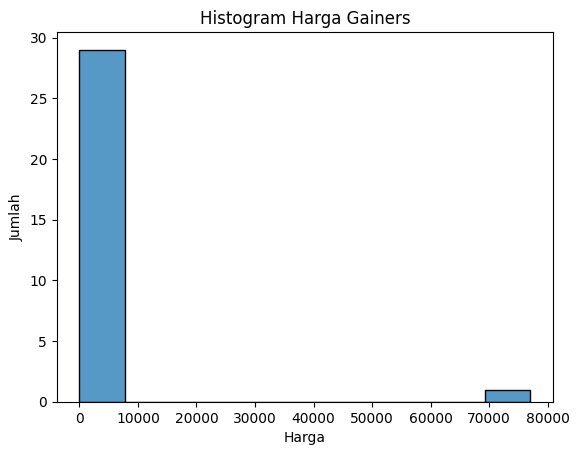

In [12]:
import matplotlib.pyplot as plt
sns.histplot(data=df_gainers, x='Price', bins=10)
plt.xlabel('Harga')
plt.ylabel('Jumlah')
plt.title('Histogram Harga Gainers')
plt.show()

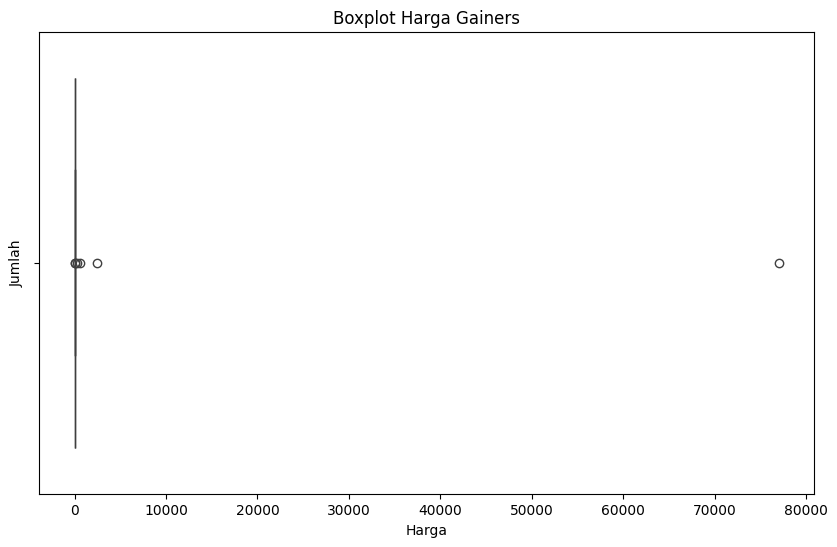

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_gainers,x='Price')
plt.xlabel('Harga')
plt.ylabel('Jumlah')
plt.title('Boxplot Harga Gainers')
plt.show()